Iteration   0 | Best Fitness: 8704.704179 | Best Position: [-2.32889659  2.49222581]
Iteration  10 | Best Fitness: 0.564455 | Best Position: [1.1045987  1.19880648]
Iteration  20 | Best Fitness: 0.002980 | Best Position: [1.00838037 1.01532177]
Iteration  30 | Best Fitness: 0.001049 | Best Position: [1.00744988 1.01565814]
Iteration  40 | Best Fitness: 0.000039 | Best Position: [1.00026112 1.00032698]
Iteration  50 | Best Fitness: 0.000004 | Best Position: [1.00057226 1.00117048]
Iteration  60 | Best Fitness: 0.000001 | Best Position: [1.00027418 1.00056257]
Iteration  70 | Best Fitness: 0.000001 | Best Position: [1.00026964 1.00053597]
Iteration  80 | Best Fitness: 0.000000 | Best Position: [1.00010517 1.00020397]
Iteration  90 | Best Fitness: 0.000000 | Best Position: [1.00006328 1.00012616]
Iteration  99 | Best Fitness: 0.000000 | Best Position: [1.00004395 1.00008695]

Final Result:
Best Position: [1.00004395 1.00008695]
Best Fitness: 0.000000


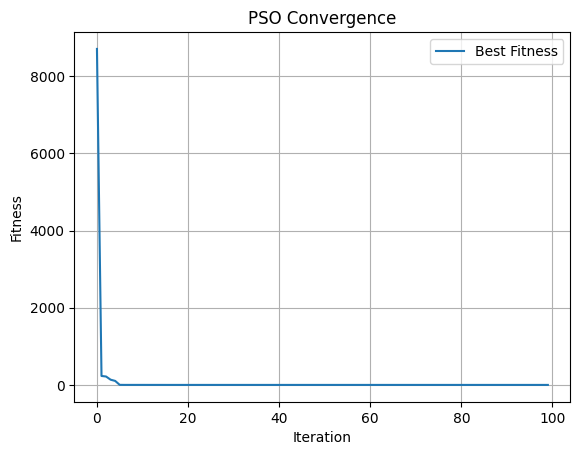

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class Particle:
    def __init__(self, bounds, num_dimensions):
        self.position = np.random.uniform(bounds[0], bounds[1], num_dimensions)
        self.velocity = np.random.uniform(-1, 1, num_dimensions)
        self.best_position = self.position.copy()
        self.best_fitness = float('inf')

class PSO:
    def __init__(self, objective_func, num_particles, num_dimensions, bounds, max_iterations, w=0.5, c1=1.0, c2=2.0):
        self.objective_func = objective_func
        self.num_particles = num_particles
        self.num_dimensions = num_dimensions
        self.bounds = bounds
        self.max_iterations = max_iterations
        self.w = w
        self.c1 = c1
        self.c2 = c2
        self.particles = [Particle(bounds, num_dimensions) for _ in range(num_particles)]
        self.global_best_position = np.zeros(num_dimensions)
        self.global_best_fitness = float('inf')
        self.history = []

    def optimize(self, verbose=True):
        for iteration in range(self.max_iterations):
            for particle in self.particles:
                fitness = self.objective_func(particle.position)
                if fitness < particle.best_fitness:
                    particle.best_fitness = fitness
                    particle.best_position = particle.position.copy()
                if fitness < self.global_best_fitness:
                    self.global_best_fitness = fitness
                    self.global_best_position = particle.position.copy()

            for particle in self.particles:
                r1 = np.random.rand(self.num_dimensions)
                r2 = np.random.rand(self.num_dimensions)
                cognitive = self.c1 * r1 * (particle.best_position - particle.position)
                social = self.c2 * r2 * (self.global_best_position - particle.position)
                particle.velocity = self.w * particle.velocity + cognitive + social
                particle.position += particle.velocity
                particle.position = np.clip(particle.position, self.bounds[0], self.bounds[1])

            self.history.append(self.global_best_fitness)

            if verbose and (iteration % 10 == 0 or iteration == self.max_iterations - 1):
                print(f"Iteration {iteration:3d} | Best Fitness: {self.global_best_fitness:.6f} | Best Position: {self.global_best_position}")

        return self.global_best_position, self.global_best_fitness

    def plot_convergence(self):
        plt.plot(self.history, label="Best Fitness")
        plt.xlabel("Iteration")
        plt.ylabel("Fitness")
        plt.title("PSO Convergence")
        plt.grid(True)
        plt.legend()
        plt.show()

# === USAGE ===

if __name__ == "__main__":
    # Define any custom function here
    def custom_function(x):
        # Example: Rastrigin function
        A = 10
        return A * sum(100*(x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)

    num_particles = 30
    num_dimensions = 2
    bounds = (-5.12, 5.12)
    max_iterations = 100

    pso = PSO(custom_function, num_particles, num_dimensions, bounds, max_iterations)
    best_position, best_fitness = pso.optimize()

    print("\nFinal Result:")
    print(f"Best Position: {best_position}")
    print(f"Best Fitness: {best_fitness:.6f}")
    pso.plot_convergence()
